In [1]:
import time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import datasets, transforms, utils
from torch.utils.data import DataLoader
%cd "C:/Users/mateo/Desktop/polymath-jr-drifting"
# This notebook uses DriftXpress; exact drift uses its separate loss/cache API in src.drift.
from src.driftXpress import *
from src.eval import *
from src.training import (
    compose_objective,
    format_epoch_losses,
    gradient_report,
    per_loss_gradient_norms,
    set_requires_grad,
)
torch.manual_seed(7)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)


C:\Users\mateo\Desktop\polymath-jr-drifting
Using: cuda


In [2]:
transform = transforms.ToTensor()

SELECTED_DIGITS = (0, 8, 2, 4, 7, 9)
DIGIT_TO_CLASS = {digit: index for index, digit in enumerate(SELECTED_DIGITS)}
CLASS_TO_DIGIT = np.asarray(SELECTED_DIGITS)

train_data = datasets.MNIST("data", train=True, download=True, transform=transform)
test_data = datasets.MNIST("data", train=False, download=True, transform=transform)

def keep_selected_digits(dataset):
    selected = torch.tensor(SELECTED_DIGITS, dtype=dataset.targets.dtype)
    mask = torch.isin(dataset.targets, selected)
    dataset.data = dataset.data[mask]
    raw_targets = dataset.targets[mask]
    dataset.targets = torch.tensor(
        [DIGIT_TO_CLASS[int(digit)] for digit in raw_targets],
        dtype=torch.long,
    )
    return dataset

train_data = keep_selected_digits(train_data)
test_data = keep_selected_digits(test_data)

BATCH_SIZE = 500

train_loader = DataLoader(
    train_data,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)
test_loader = DataLoader(
    test_data,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

print("Selected digits:", SELECTED_DIGITS)
print("Train samples:", len(train_data))
print("Test samples:", len(test_data))


Selected digits: (0, 8, 2, 4, 7, 9)
Train samples: 35788
Test samples: 6005


In [3]:
class f(nn.Module):
    def __init__(self, input_dim=784, latent_dim=16, num_classes=6, label_dim=16):
        super().__init__()
        self.latent_dim = latent_dim
        self.num_classes = num_classes
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 192), nn.LeakyReLU(0.2),
            nn.Linear(192, 96), nn.LeakyReLU(0.2),
        )
        self.fc_mu = nn.Linear(96, latent_dim)
        self.fc_var = nn.Linear(96, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 96), nn.LeakyReLU(0.2),
            nn.Linear(96, 192), nn.LeakyReLU(0.2),
            nn.Linear(192, input_dim), nn.Sigmoid(),
        )
        self.embedding = nn.Embedding(num_classes, label_dim)
        self.generator = nn.Sequential(
            nn.Linear(latent_dim + label_dim, 48), nn.SiLU(),
            nn.Linear(48, 48), nn.SiLU(),
            nn.Linear(48, 48), nn.SiLU(),
            nn.Linear(48, latent_dim),
        )

    def reparameterize(self, mu, logvar):
        return mu + torch.randn_like(logvar) * torch.exp(0.5 * logvar)

    def get_latent(self, x):
        h = self.encoder(x)
        mu, logvar = self.fc_mu(h), self.fc_var(h)
        return mu, logvar, self.reparameterize(mu, logvar)

    def encode_mu(self, x):
        return self.fc_mu(self.encoder(x))

    def decode(self, z):
        return self.decoder(z)

    def generate(self, noise, labels):
        h = torch.cat([noise, self.embedding(labels.long())], dim=1)
        z = self.generator(h)
        return z, self.decode(z)


In [4]:
model = f()
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params}")
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {trainable_params}")

Total parameters: 351088
Trainable parameters: 351088


In [5]:
# Keep the drift field fixed while allowing gradients through the re-encoded latent.
def drift_loss(generated, landmarks, K_uu_inv_sqrt, Ap, bp, T):
    with torch.no_grad():
        V = compute_V(generated.detach(), landmarks, K_uu_inv_sqrt, Ap, bp, T)
        frozen_targets = (generated.detach() + V).detach()
    return F.mse_loss(generated, frozen_targets), V


In [6]:
def build_conditional_drift_cache(model, data_loader, num_classes, num_landmarks, T):
    # Build fixed class-conditional attraction summaries once.
    model.eval()
    references = {digit: [] for digit in range(num_classes)}
    with torch.no_grad():
        for images, labels in data_loader:
            x = images.to(device, non_blocking=True).flatten(start_dim=1)
            _, _, z = model.get_latent(x)
            labels = labels.to(device, non_blocking=True)
            for digit in range(num_classes):
                mask = labels == digit
                if mask.any():
                    references[digit].append(z[mask].detach())

    cache = {}
    bank = []
    for digit in range(num_classes):
        if not references[digit]:
            raise ValueError(f"No reference samples found for digit {digit}.")
        support = torch.cat(references[digit], dim=0)
        bank.append(support)
        landmarks = select_landmarks(support, num_landmarks)
        W = build_nystrom_cache(landmarks, T)
        A, b = pre_compute_summaries(support, landmarks, W, T)
        cache[digit] = (landmarks, W, A, b)
    return cache, torch.cat(bank, dim=0)


def conditional_drift_loss(generated, labels, cache, T):
    total = generated.new_zeros(())
    field = torch.zeros_like(generated)
    batch_size = generated.shape[0]
    for digit_tensor in torch.unique(labels):
        digit = int(digit_tensor.item())
        mask = labels == digit
        landmarks, W, A, b = cache[digit]
        digit_loss, digit_field = drift_loss(
            generated[mask], landmarks, W, A, b, T
        )
        total = total + (mask.float().sum() / batch_size) * digit_loss
        field[mask] = digit_field
    return total, field

def training_loop(num_epochs, T, num_landmarks,
                  lambda_kl, lambda_drift, lambda_var, lambda_cov,
                  lambda_representation=1.0, loss_scale=1.0,
                  batch_size=1000, lr=1e-4):
    model = f(784, LATENT_DIM, NUM_CLASSES).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=lr)
    train_losses, recon_losses, kl_losses = [], [], []
    drift_losses, var_losses, covar_losses = [], [], []
    average_V, evolution = [], []
    space_evolution = []

    print("Building fixed conditional attraction caches...")
    t0 = time.perf_counter()
    cache, _ = build_conditional_drift_cache(
        model, train_loader, NUM_CLASSES, num_landmarks, T
    )
    print(f"Fixed attraction caches built in {(time.perf_counter() - t0) / 60:.2f} minutes")

    # Fixed probes make latent-space and image snapshots comparable across epochs.
    probe_images, probe_labels = next(iter(test_loader))
    probe_x = probe_images[:500].to(device, non_blocking=True).flatten(start_dim=1)
    probe_labels = probe_labels[:500].to(device, non_blocking=True)
    snapshot_labels = torch.arange(NUM_CLASSES, device=device)
    snapshot_noise = torch.randn(NUM_CLASSES, model.latent_dim, device=device)

    def capture_space_snapshot(epoch, stage):
        model.eval()
        with torch.no_grad():
            real_z = model.encode_mu(probe_x)
            raw_z, generated_images = model.generate(snapshot_noise, snapshot_labels)
            generated_z = model.encode_mu(generated_images)
        space_evolution.append({
            "epoch": epoch,
            "stage": stage,
            "real_latents": real_z.cpu().numpy(),
            "generated_raw_latents": raw_z.cpu().numpy(),
            "generated_reencoded_latents": generated_z.cpu().numpy(),
            "generated_images": generated_images.view(-1, 1, 28, 28).cpu().numpy(),
            "generated_labels": snapshot_labels.cpu().numpy(),
        })

    capture_space_snapshot(-1, "before training")
    print("Fully joint conditional training started")
    snapshots = set(range(0, num_epochs + 1, max(1, num_epochs // 5)))
    snapshots.add(num_epochs)

    for epoch in range(num_epochs + 1):
        model.train()
        items = {k: 0.0 for k in
                 ("total", "recon", "kl", "drift", "var", "covar", "V")}
        last_pos, last_neg = None, None
        for images, labels in train_loader:
            x = images.to(device, non_blocking=True).flatten(start_dim=1)
            labels = labels.to(device, non_blocking=True)
            noise = torch.randn(x.shape[0], model.latent_dim, device=device)
            mu, logvar, z_pos = model.get_latent(x)
            x_recon = model.decode(z_pos)
            z_raw, x_neg = model.generate(noise, labels)
            z_neg = model.encode_mu(x_neg)

            L_drift, V = conditional_drift_loss(z_neg, labels, cache, T)
            L_var = variance_loss(mu) + variance_loss(z_neg)
            L_cov = covariance_loss(mu) + covariance_loss(z_neg)
            L_recon, L_kl = recon_loss(x_recon, x), kl_loss(mu, logvar)
            loss, _ = compose_objective(
                {
                    "recon": L_recon,
                    "kl": L_kl,
                    "drift": L_drift,
                    "var": L_var,
                    "covar": L_cov,
                },
                {
                    "kl": lambda_kl,
                    "drift": lambda_drift,
                    "var": lambda_var,
                    "covar": lambda_cov,
                },
                lambda_representation=lambda_representation,
                loss_scale=loss_scale,
            )
            if not torch.isfinite(loss):
                raise FloatingPointError(f"Non-finite loss at epoch {epoch}: {loss.item()}")
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()

            items["total"] += loss.item()
            items["recon"] += L_recon.item()
            items["kl"] += L_kl.item()
            items["drift"] += L_drift.item()
            items["var"] += L_var.item()
            items["covar"] += L_cov.item()
            items["V"] += V.norm(dim=1).mean().item()
            last_pos, last_neg = z_pos.detach(), z_neg.detach()

        n = len(train_loader)
        for key in items:
            items[key] /= n
        train_losses.append(items["total"])
        recon_losses.append(items["recon"])
        kl_losses.append(items["kl"])
        drift_losses.append(items["drift"])
        var_losses.append(items["var"])
        covar_losses.append(items["covar"])
        average_V.append(items["V"])
        if epoch in snapshots:
            evolution.append({"epoch": epoch, "pos": last_pos.cpu().numpy(),
                               "neg": last_neg.cpu().numpy()})
            capture_space_snapshot(epoch, "joint training")
        if epoch < 20 or epoch % 10 == 0 or epoch == num_epochs:
            print(f"-------- Epoch {epoch} --------")
            print(f"total={items['total']:.6f}")
            print(f"recon={items['recon']:.6f}    scaled={loss_scale * lambda_representation * items['recon']:.6f}")
            print(f"kl={items['kl']:.6f}    scaled={loss_scale * lambda_representation * lambda_kl * items['kl']:.6f}")
            print(f"drift={items['drift']:.6f}    scaled={loss_scale * lambda_drift * items['drift']:.6f}")
            print(f"var={items['var']:.6f}    scaled={loss_scale * lambda_representation * lambda_var * items['var']:.6f}")
            print("distances", torch.cdist(z_pos[:50], z_pos[:50]).mean().item())
            print(f"covar={items['covar']:.6f}    scaled={loss_scale * lambda_representation * lambda_cov * items['covar']:.6f}")
            print(f"average |V|={items['V']:.6f}")
            print(f"latent std positive={last_pos.std(dim=0).mean().item():.6f}")
            print(f"latent std negative={last_neg.std(dim=0).mean().item():.6f}")

    elapsed = (time.perf_counter() - t0) / 60
    print(f"Finished. Training took {elapsed:.2f} minutes")
    return (model, train_losses, recon_losses, kl_losses,
            drift_losses, var_losses, covar_losses, average_V, evolution, space_evolution)


In [7]:
# Algorithm 3: fully joint conditional training with image re-encoding for drift.
NUM_CLASSES = 6
LATENT_DIM = 32
NUM_EPOCHS = 100
NUM_LANDMARKS = 200
TEMPERATURE = 1
LAMBDA_KL = 1e-5
LAMBDA_DRIFT = 500.0
LAMBDA_VAR = 0.0
LAMBDA_COV = 0.0
LAMBDA_REPRESENTATION = 20.0
LOSS_SCALE = 1.0  # Global multiplier; leave at 1 unless intentionally testing it.

f_trained, losses, recon_losses, kl_losses, drift_losses, var_losses, covar_losses, average_V, evolution, space_evolution = training_loop(
    NUM_EPOCHS, TEMPERATURE, NUM_LANDMARKS, LAMBDA_KL, LAMBDA_DRIFT,
    LAMBDA_VAR, LAMBDA_COV,
    lambda_representation=LAMBDA_REPRESENTATION,
    loss_scale=LOSS_SCALE,
    batch_size=BATCH_SIZE, lr=1e-4,
)


Building fixed conditional attraction caches...
Fixed attraction caches built in 0.13 minutes
Fully joint conditional training started
-------- Epoch 0 --------
total=4.654609
recon=0.212084    scaled=4.241674
kl=0.191302    scaled=0.000038
drift=0.000826    scaled=0.412897
var=2.964393    scaled=0.000000
distances 7.799588680267334
covar=0.000001    scaled=0.000000
average |V|=0.160608
latent std positive=1.028355
latent std negative=0.000058
-------- Epoch 1 --------
total=2.896084
recon=0.125249    scaled=2.504989
kl=3.030819    scaled=0.000606
drift=0.000781    scaled=0.390488
var=2.928563    scaled=0.000000
distances 10.981694221496582
covar=0.001642    scaled=0.000000
average |V|=0.156619
latent std positive=1.403138
latent std negative=0.004409
-------- Epoch 2 --------
total=1.825990
recon=0.073547    scaled=1.470946
kl=18.421053    scaled=0.003684
drift=0.000703    scaled=0.351360
var=2.820209    scaled=0.000000
distances 12.268022537231445
covar=0.033688    scaled=0.000000
av

In [8]:
f_trained.train()
images, labels = next(iter(train_loader))
x = images.to(device).flatten(start_dim=1)
labels = labels.to(device)
noise = torch.randn(x.shape[0], f_trained.latent_dim, device=device)
mu, logvar, z_pos = f_trained.get_latent(x)
z_raw, x_neg = f_trained.generate(noise, labels)
z_neg = f_trained.encode_mu(x_neg)
cache, _ = build_conditional_drift_cache(
    f_trained, train_loader, NUM_CLASSES, NUM_LANDMARKS, TEMPERATURE
)
L_drift, V = conditional_drift_loss(z_neg, labels, cache, TEMPERATURE)
print(gradient_report(L_drift, f_trained))


{'encoder': {'total_norm': 0.6856458088002584, 'nonzero_parameters': 6, 'parameter_count': 8}, 'decoder': {'total_norm': 0.12116181387953819, 'nonzero_parameters': 6, 'parameter_count': 6}, 'generator': {'total_norm': 0.15247439805729965, 'nonzero_parameters': 9, 'parameter_count': 9}}


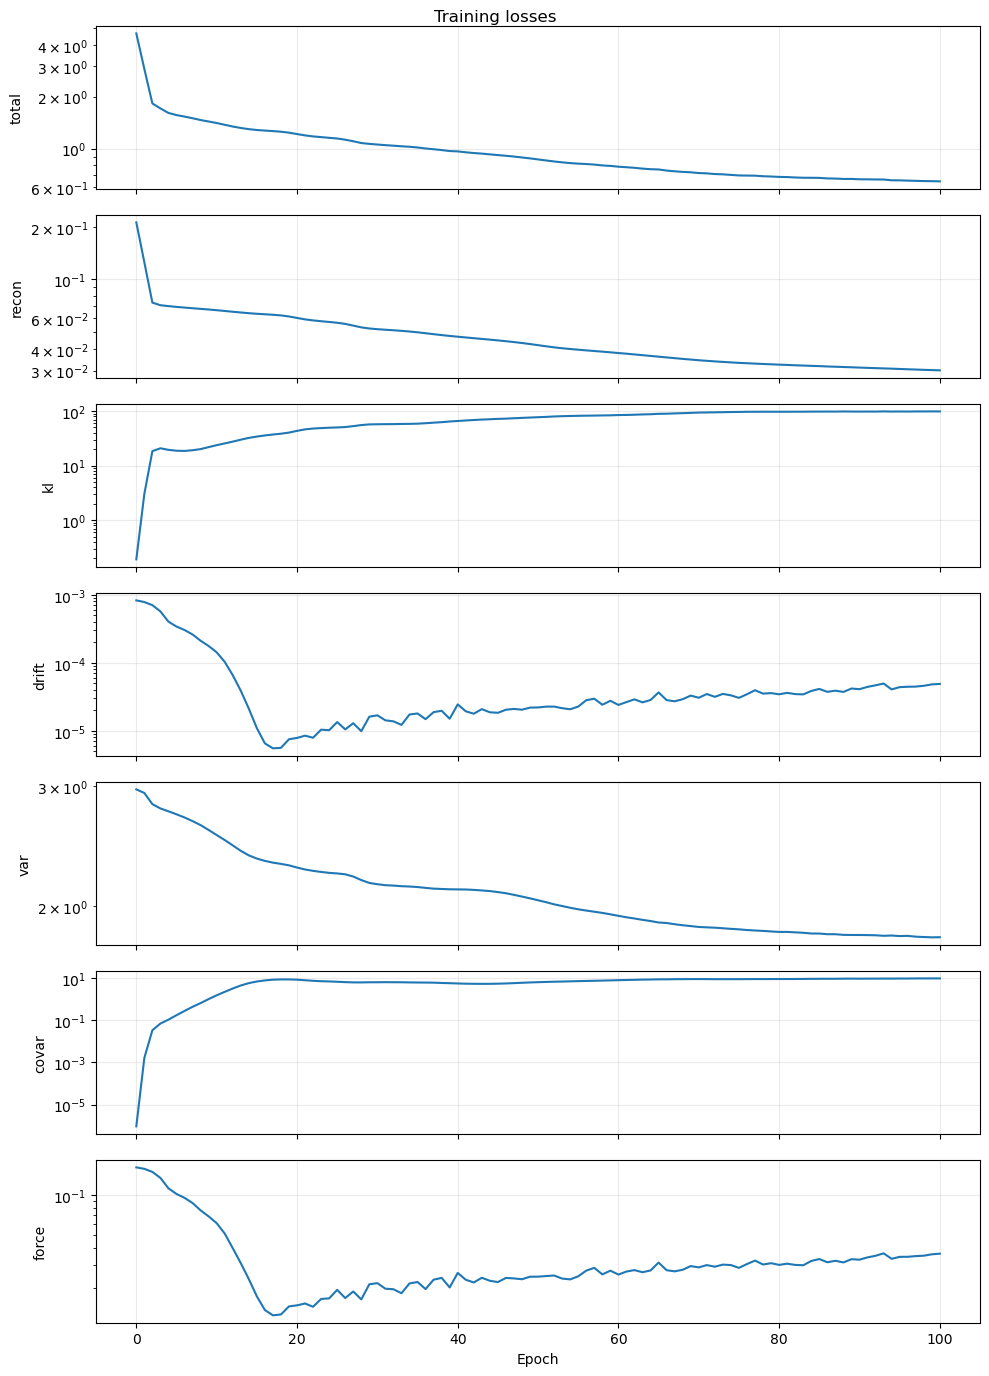

In [9]:
history = {
    "total": losses, "recon": recon_losses, "kl": kl_losses,
    "drift": drift_losses, "var": var_losses,
    "covar": covar_losses, "force": average_V,
}
fig, axes = plot_loss_history(history)
plt.show()


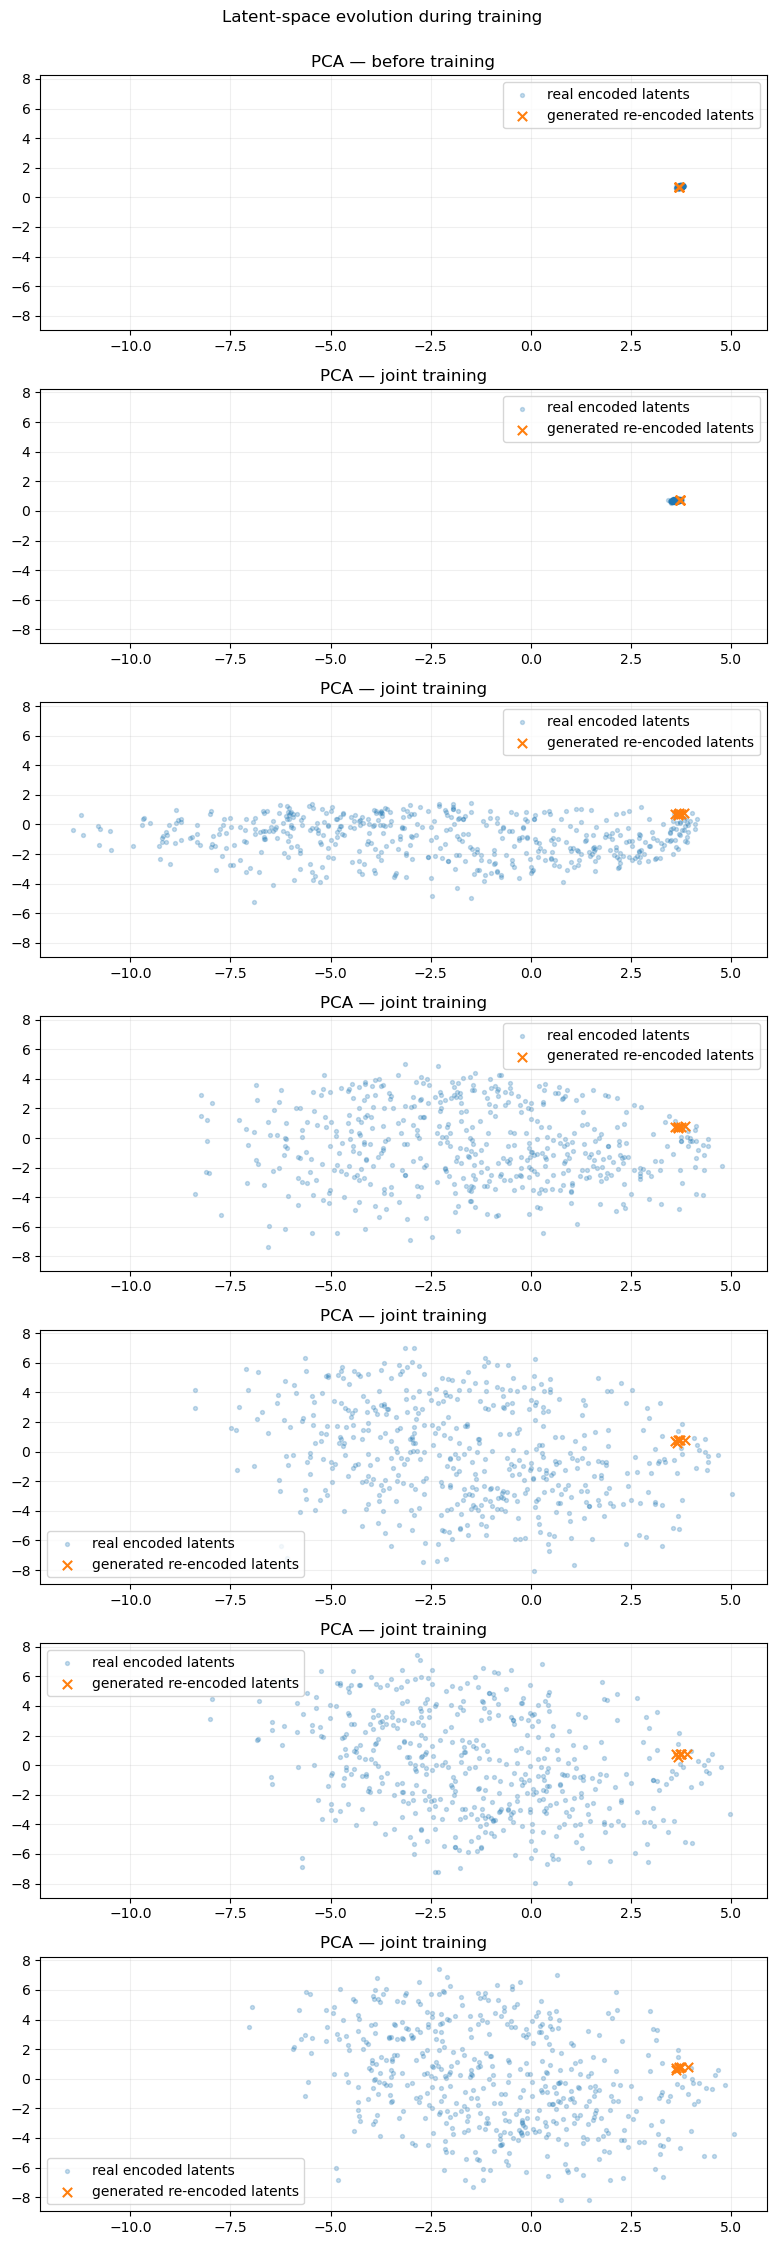

C:\Users\mateo\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


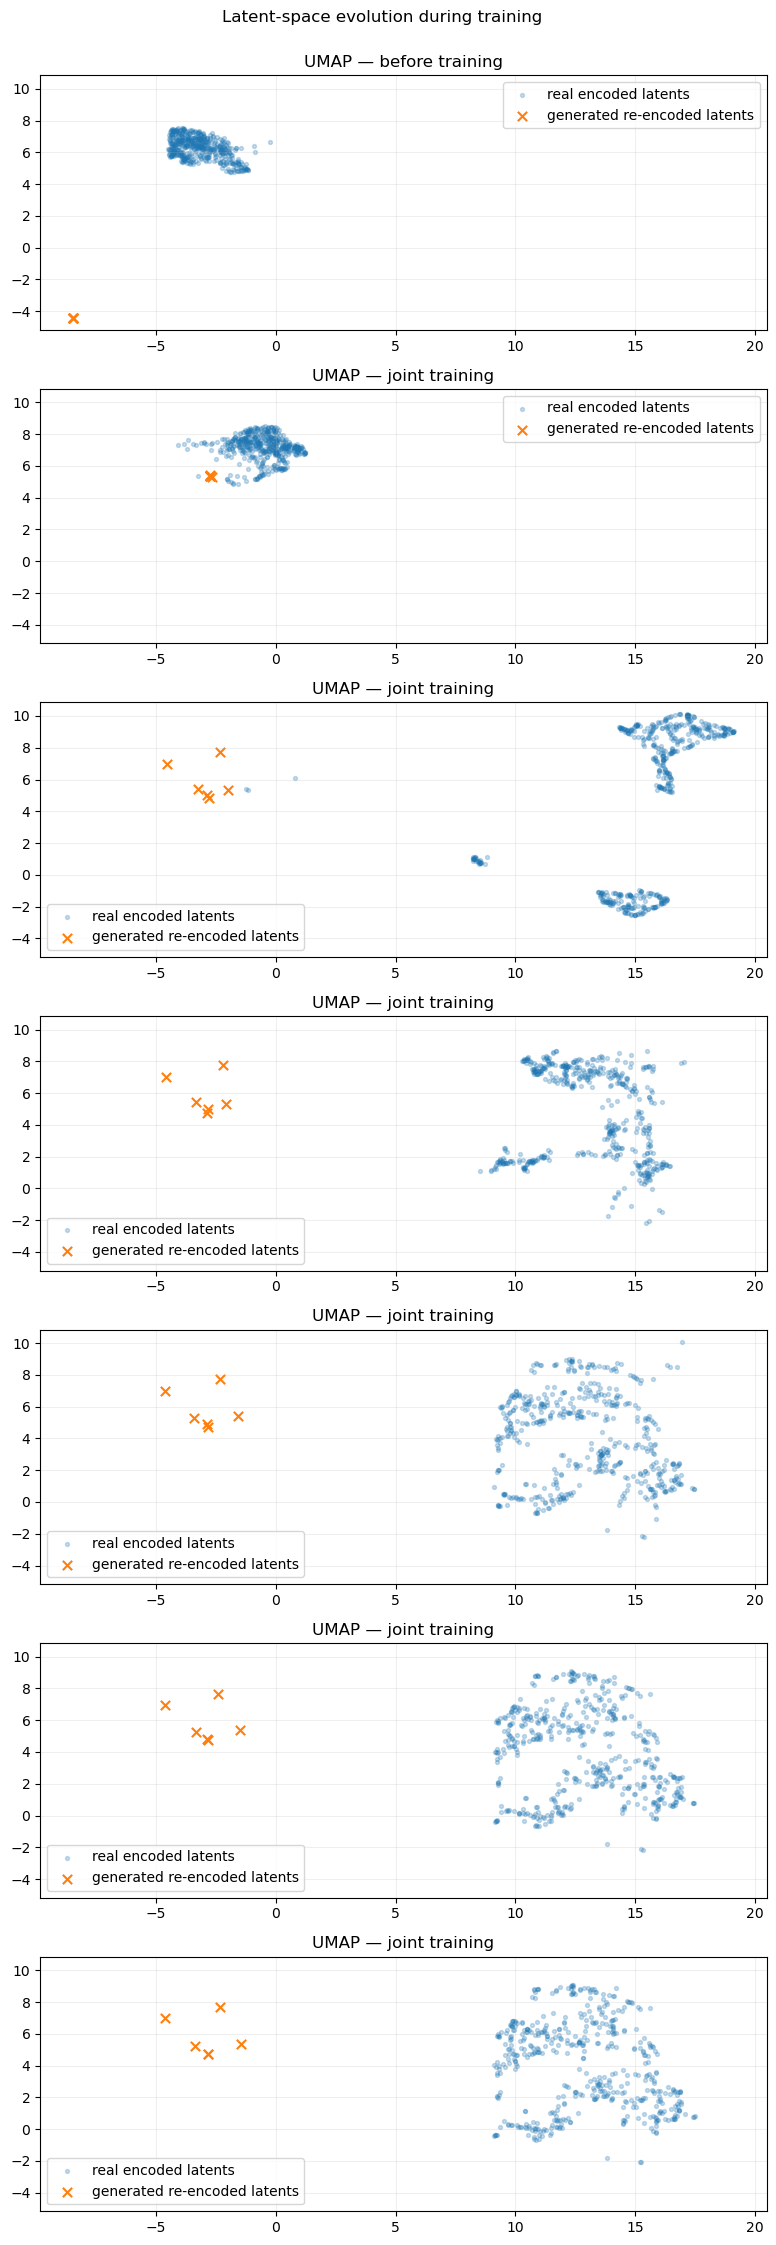

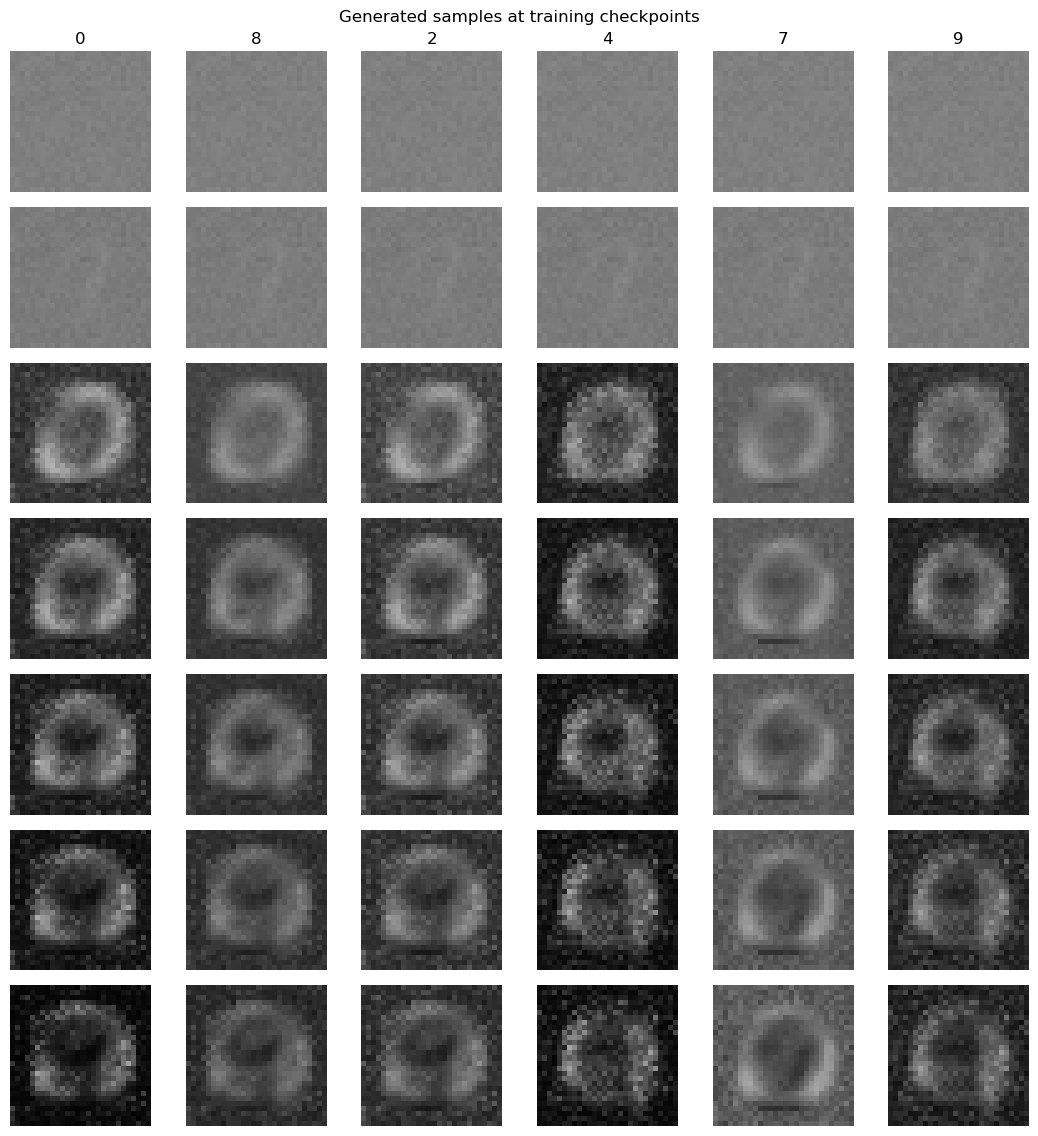

In [10]:
def plot_latent_space_evolution(space_evolution, method="pca", max_real_points=500):
    """Plot real and generated latents using one shared coordinate system."""
    if not space_evolution:
        raise ValueError("space_evolution is empty; rerun the training cell first.")

    real_parts = [record["real_latents"][:max_real_points] for record in space_evolution]
    generated_parts = [record["generated_reencoded_latents"] for record in space_evolution]
    real_counts = [part.shape[0] for part in real_parts]
    generated_counts = [part.shape[0] for part in generated_parts]
    combined = np.concatenate([*real_parts, *generated_parts], axis=0)

    method = method.lower()
    if method == "pca":
        from sklearn.decomposition import PCA
        reducer = PCA(n_components=2, random_state=7)
    elif method == "umap":
        import umap
        reducer = umap.UMAP(
            n_components=2,
            n_neighbors=15,
            min_dist=0.2,
            metric="euclidean",
            random_state=7,
        )
    else:
        raise ValueError("method must be 'pca' or 'umap'.")

    embedded = reducer.fit_transform(combined)
    real_offsets = np.cumsum([0, *real_counts])
    generated_offset = sum(real_counts)
    generated_offsets = np.cumsum([generated_offset, *generated_counts])

    figure, axes = plt.subplots(
        len(space_evolution),
        1,
        figsize=(8, 3.2 * len(space_evolution)),
        squeeze=False,
    )
    axes = axes[:, 0]
    x_min, x_max = embedded[:, 0].min(), embedded[:, 0].max()
    y_min, y_max = embedded[:, 1].min(), embedded[:, 1].max()
    x_pad = max(1e-6, 0.05 * (x_max - x_min))
    y_pad = max(1e-6, 0.05 * (y_max - y_min))

    for index, record in enumerate(space_evolution):
        real_start, real_end = real_offsets[index], real_offsets[index + 1]
        gen_start, gen_end = generated_offsets[index], generated_offsets[index + 1]
        axis = axes[index]
        axis.scatter(
            embedded[real_start:real_end, 0],
            embedded[real_start:real_end, 1],
            s=8,
            alpha=0.25,
            label="real encoded latents",
        )
        axis.scatter(
            embedded[gen_start:gen_end, 0],
            embedded[gen_start:gen_end, 1],
            s=45,
            marker="x",
            linewidths=1.5,
            label="generated re-encoded latents",
        )
        axis.set_title(f"{method.upper()} — {record['stage']}")
        axis.set_xlim(x_min - x_pad, x_max + x_pad)
        axis.set_ylim(y_min - y_pad, y_max + y_pad)
        axis.grid(alpha=0.2)
        axis.legend()

    figure.suptitle("Latent-space evolution during training", y=1.0)
    figure.tight_layout()
    return figure, axes


def plot_generated_sample_evolution(space_evolution):
    """Show the same generated labels/noise at every checkpoint."""
    if not space_evolution:
        raise ValueError("space_evolution is empty; rerun the training cell first.")

    n_rows = len(space_evolution)
    n_columns = space_evolution[0]["generated_images"].shape[0]
    figure, axes = plt.subplots(
        n_rows,
        n_columns,
        figsize=(1.8 * n_columns, 1.65 * n_rows),
        squeeze=False,
    )
    digits = CLASS_TO_DIGIT[space_evolution[0]["generated_labels"]]

    for row, record in enumerate(space_evolution):
        for column in range(n_columns):
            axis = axes[row, column]
            axis.imshow(record["generated_images"][column, 0], cmap="gray", vmin=0, vmax=1)
            axis.axis("off")
            if row == 0:
                axis.set_title(str(int(digits[column])))
        axes[row, 0].set_ylabel(
            record["stage"],
            rotation=0,
            ha="right",
            va="center",
            fontsize=8,
            labelpad=12,
        )

    figure.suptitle("Generated samples at training checkpoints")
    figure.tight_layout()
    return figure, axes


fig_space_pca, axes_space_pca = plot_latent_space_evolution(space_evolution, method="pca")
plt.show()

try:
    fig_space_umap, axes_space_umap = plot_latent_space_evolution(space_evolution, method="umap")
    plt.show()
except Exception as error:
    print(f"UMAP could not be plotted ({type(error).__name__}: {error}). PCA was plotted above.")

fig_generation_evolution, axes_generation_evolution = plot_generated_sample_evolution(space_evolution)
plt.show()


In [11]:
# One reusable post-training call: it collects real encoder means and
# conditional generated latents/images, then computes latent SWD/FID and class metrics.
post_eval = evaluate_latent_model(
    f_trained,
    test_loader,
    device=device,
    n_samples=2048,
    n_classes=NUM_CLASSES,
    class_to_label=CLASS_TO_DIGIT,
    include_mmd=False,
    include_fid=True,
)

samples = post_eval["samples"]
real_latents = samples["real_latents"]
generated_latents = samples["generated_latents"]
real_pixels = samples["real_images"]
generated_pixels = samples["generated_images"]
real_class_labels = samples["real_class_ids"]
generated_class_labels = samples["generated_class_ids"]
real_labels = samples["real_labels"]
generated_labels = samples["generated_labels"]
metrics = post_eval["metrics"]
latent_stats = post_eval["statistics"]

print("Latent-space metrics:")
for name, value in metrics.items():
    print(f"{name}: {value:.6f}")


Latent-space metrics:
sliced_wasserstein: 1.052673
fid: 69.214477
class_coverage: 1.000000
class_entropy: 0.999253


In [12]:
# This is the same compact metric interface in pixel space.
# Its FID is a pixel-space Fréchet distance; use evaluate_mnist_generation with a
# frozen evaluator when you specifically want learned MNIST-feature FID.
pixel_metrics = evaluate_generation(
    real_pixels,
    generated_pixels,
    generated_labels=generated_class_labels,
    n_classes=NUM_CLASSES,
    include_mmd=False,
)
print("Pixel-space metrics:")
for name, value in pixel_metrics.items():
    print(f"{name}: {value:.6f}")


Pixel-space metrics:
sliced_wasserstein: 0.202232
fid: 79.497535
class_coverage: 1.000000
class_entropy: 0.999253


In [13]:
print("Latent statistics:")
for name, value in latent_stats.items():
    print(f"{name}: {value:.6f}")


Latent statistics:
real_latent_mean: -0.054531
generated_latent_mean: 0.004220
real_latent_std: 1.081796
generated_latent_std: 0.295513
generated_to_real_std_ratio: 0.273169
real_total_correlation: 71.363964
generated_total_correlation: 87.626517


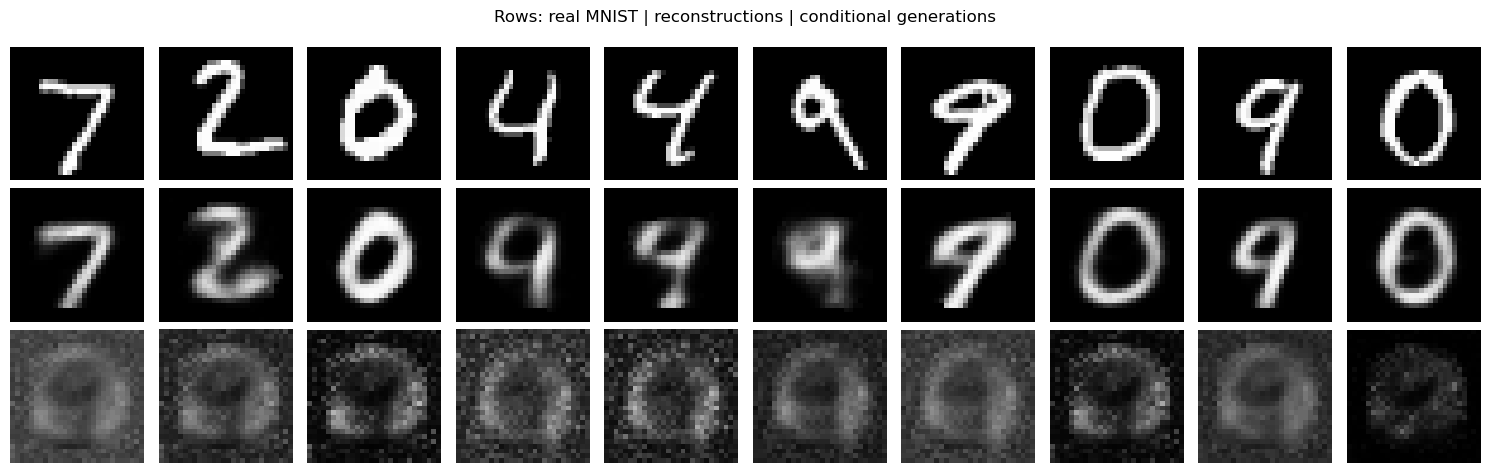

In [14]:
fig, axes = plot_conditional_mnist_results(
    f_trained,
    test_loader,
    device=device,
    samples=10,
    use_mean_for_reconstruction=True,
)
plt.show()


C:\Users\mateo\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\mateo\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


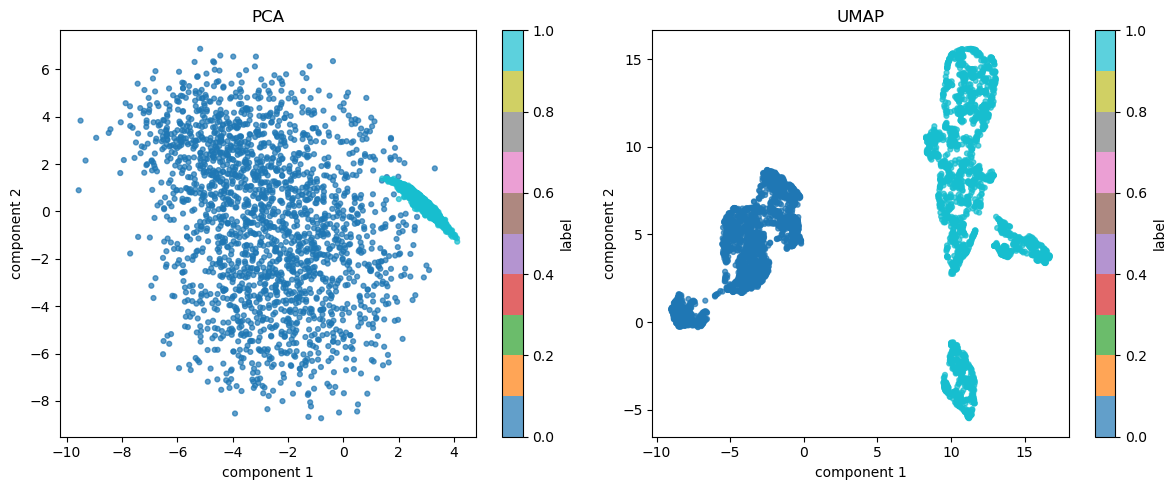

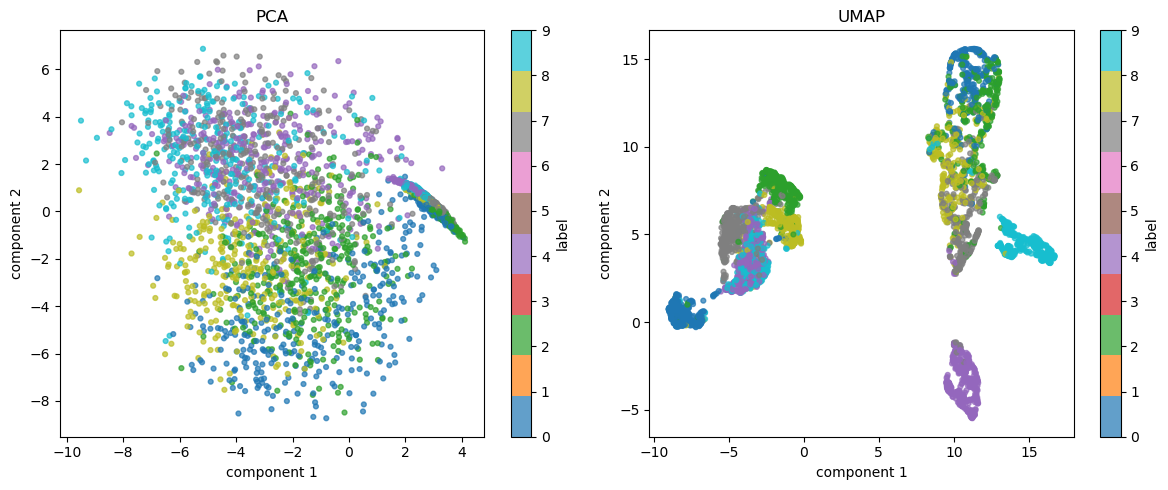

In [15]:
projection_figures = plot_real_generated_projections(
    real_latents,
    generated_latents,
    real_labels=real_labels,
    generated_labels=generated_labels,
    methods=("pca", "umap"),
)
plt.show()
